# Histogramas

Tanto OpenCV como Numpy tienen funciones para calcular el histograma en un sólo canal.

La función `np.histogram` de numpy es más sencilla de utilizar y sólo recibe tres parámetros: la matriz con la imagen, el número de *bins* para calcular el histograma y, por último, los valores inicial y final de los *bins*.
La salida de esta función son dos arrays, el primero conteniendo el número de píxeles de cada *bin* y el segundo, los límites de cada bin.

/content
/content


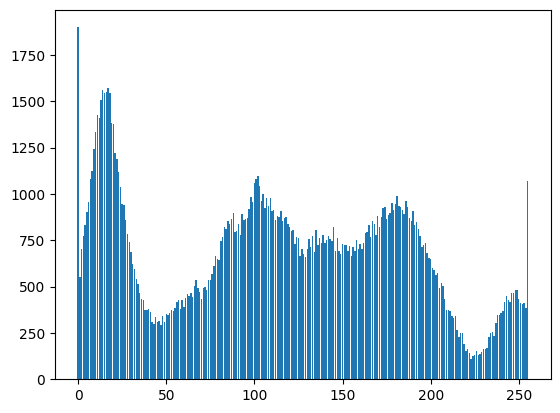

In [3]:
import numpy as np
import cv2
%matplotlib inline
from matplotlib import pyplot as plt
!pwd
%cd /content

im = cv2.imread('/content/drive/MyDrive/res/butterfly.jpg', cv2.IMREAD_GRAYSCALE)

hist_count, hist_bins = np.histogram(im, 256, [0,256])
plt.bar(range(0,256), hist_count)
plt.show()


## Operaciones con histogramas

### Modificación del rango dinámico
La librería `skimage` contiene la función `rescale_intensity` que permite escalar los valores de intensidad de la imagen. Esta función toma un parámetro obligatorio, la imagen de entrada, y dos parámetros opcionales (`in_range`, `out_range`) mediante los que se pueden especificar los valores mínimos y máximos a escalar.  Aunque existen varias opciones, la forma más habitual de utilizar esta función es pasar `image` a la variable `in_range` y una tupla con los valores mínimos y máximos a la variable `out_range`.

Si no se incluyen estos parámetros opcionales, la imagen se escala a los valores mínimos y máximos permitidos por el tipo de la imagen (0.0 y 1.0 en caso de `float` ó 0 y 255 en caso de `uint8`).

Si estamos trabajando con valores enteros es necesario convertir el resultado a formato `uint8` usando, por ejemplo, `astype(np.uint8)`.

10 50


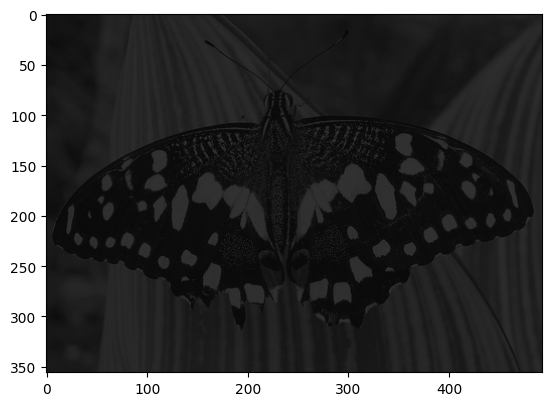

In [4]:
from skimage.exposure import rescale_intensity

out = rescale_intensity(im, in_range='image', out_range=(10,50)).astype(np.uint8)
print(np.min(out), np.max(out))

# IMPORTANTE!!!
# Forzamos los valores minimos y maximos de plt.imshow
# para que no escale las intensidades de la imagen
plt.imshow(out, cmap='gray', vmin=0, vmax=255)
plt.show()

### Ejercicio
Amplía el rango dinámico de la imagen `out` a [0,255]. Visualiza la nueva imagen y el histograma generado. Cuántos niveles de gris diferentes tiene la nueva imagen? Por qué?

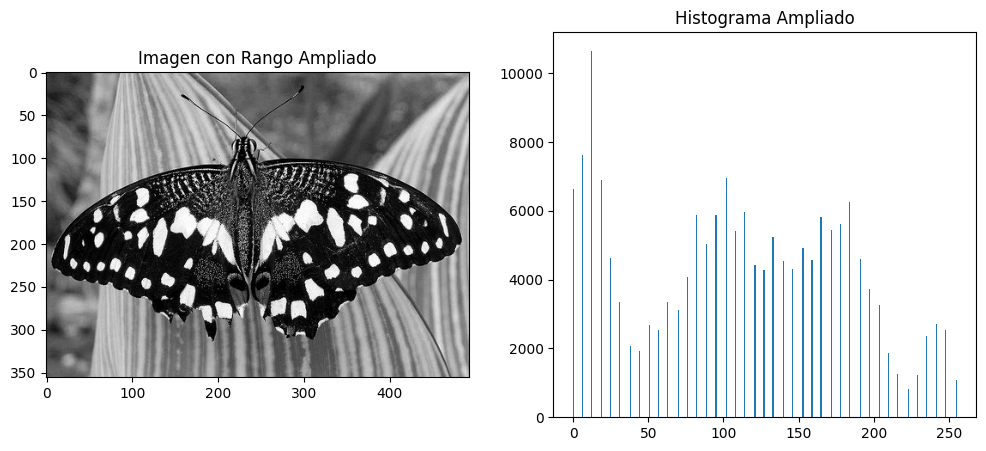

La nueva imagen tiene 41 niveles de gris diferentes.


In [5]:
# Ampliamos el rango dinámico de la imagen 'out' a [0, 255]
out_expanded = rescale_intensity(out, in_range='image', out_range=(0, 255)).astype(np.uint8)

# Calculamos el histograma
hist_count_exp, _ = np.histogram(out_expanded, 256, [0, 256])

# Visualizamos la nueva imagen y su histograma
f, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(out_expanded, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Imagen con Rango Ampliado')

ax[1].bar(range(0, 256), hist_count_exp)
ax[1].set_title('Histograma Ampliado')
plt.show()

# Contamos los niveles de gris diferentes
niveles_diferentes = len(np.unique(out_expanded))
print(f"La nueva imagen tiene {niveles_diferentes} niveles de gris diferentes.")


### Compresión y expansión del rango dinámico

Por una parte, aplicando el logaritmo a una image reduce el contraste de las regiones más claras, mejorando las zonas más oscuras. Por otra parte, el exponencial permite realizar la operación contraria, esto es, aumentar el contraste de las regiones más claras.

0.0 5.545177444479562


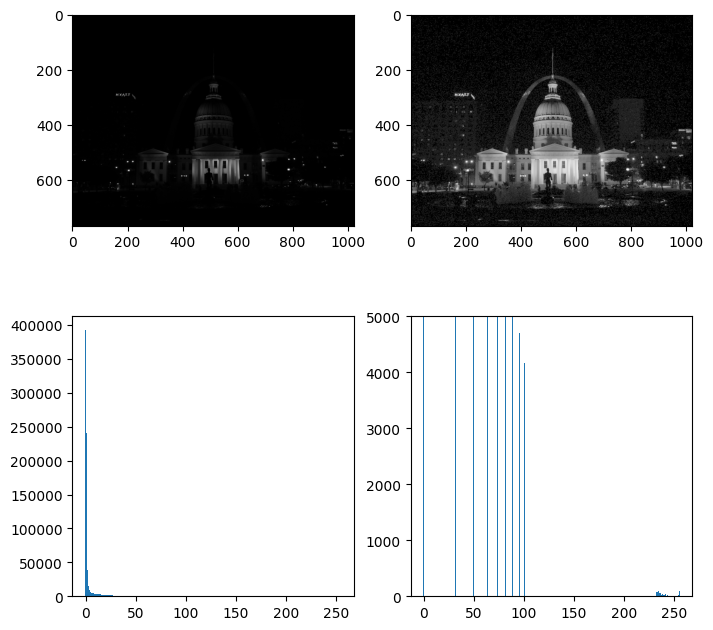

In [6]:
plt.rcParams["figure.figsize"] = [8,8] # Establece el tamaño predeterminado de las figuras de matplotlib en 8x8 pulgadas.

im = cv2.imread("/content/drive/MyDrive/res/building.jpg",cv2.IMREAD_GRAYSCALE)
hist_count, _ = np.histogram(im, 256, [0,256])    # Calcula el histograma de la imagen con 256 bins que cubren el rango de intensidades de 0 a 255.


im_log = np.log(im.astype(float) + 1)   # log de 0 no existe: sumamos 1 a toda la imagen.
                                        # Aplica una transformación logarítmica a la imagen original.
                                        # Esto se hace para mejorar el contraste en áreas de baja intensidad.
                                        # Se suma 1 a la imagen antes de tomar el logaritmo para evitar el logaritmo de 0.
print(np.min(im_log), np.max(im_log))


# Normalizar la imagen entre 0 y 1
min_im_log, max_im_log = np.min(im_log), np.max(im_log)
im_log = (im_log - min_im_log) / (max_im_log - min_im_log)

hist_count_im_log, _ = np.histogram(im_log, 256)

f, ax = plt.subplots(2,2)
ax[0,0].imshow(im, cmap='gray')
ax[0,1].imshow(im_log, cmap='gray')
plt.ylim([0,5000])
ax[1,0].bar(range(0,256), hist_count)
ax[1,1].bar(range(0,256), hist_count_im_log)
plt.show()



### Histograma de la Imagen Original

1. **Distribución de Intensidades**:
   - La mayoría de los valores de intensidad están concentrados cerca de 0, lo que indica que la imagen tiene muchas áreas oscuras.
   - La frecuencia de los valores de intensidad disminuye rápidamente a medida que los valores aumentan, lo que sugiere que hay pocas áreas claras en la imagen.


### Histograma de la Imagen Transformada Logarítmicamente

1. **Distribución de Intensidades**:
   - El histograma tiene varios picos distintos en intervalos específicos, lo que indica que la transformación logarítmica ha redistribuido los valores de intensidad, mejorando el contraste en áreas de baja intensidad.
   - La mayoría de los datos están concentrados en estos picos, con muy pocos valores en otros lugares.

### Comparación

- **Imagen Original**: Predominancia de píxeles oscuros, bajo contraste.
- **Imagen Transformada**: Mejor contraste, redistribución de intensidades, resaltando detalles en áreas de baja intensidad.


### Ejercicio
Aplica la función `np.exp` a la imagen `town.jpg`. Visualiza la imagen antes y despues de aplicar la función. *Hint*: convierte la imagen a float y normaliza los valores de los píxeles entre 0 y 1 antes de calcular el exponencial.

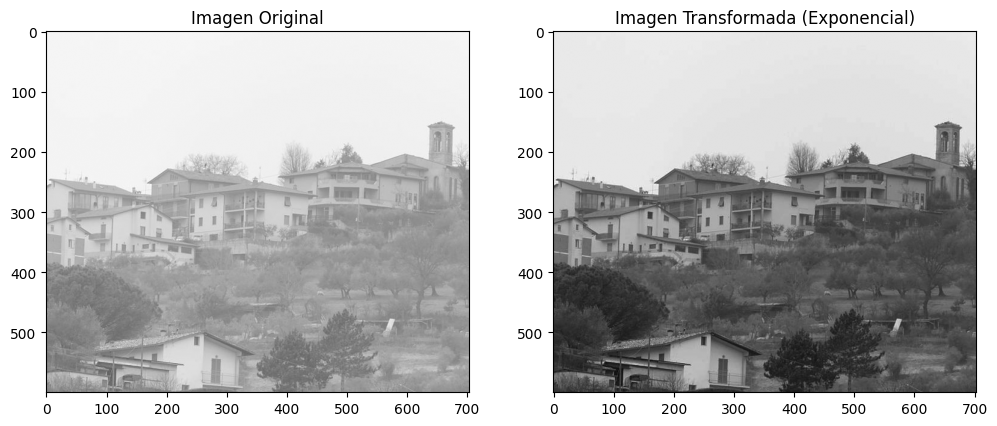

In [7]:
# Cargar la imagen town.jpg
im_town = cv2.imread("/content/drive/MyDrive/res/town.jpg", cv2.IMREAD_GRAYSCALE)

# 1. Convertir la imagen a float
im_float = im_town.astype(float)

# 2. Normalizar los valores entre 0 y 1
im_norm = (im_float - np.min(im_float)) / (np.max(im_float) - np.min(im_float))

# 3. Aplicar la función exponencial
im_exp = np.exp(im_norm)

# 4. Normalizar el resultado nuevamente para la visualización correcta (ya que np.exp(1) es ~2.71)
im_exp_norm = (im_exp - np.min(im_exp)) / (np.max(im_exp) - np.min(im_exp))

# Visualizar la imagen antes y después
f, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im_town, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Imagen Original')

ax[1].imshow(im_exp_norm, cmap='gray', vmin=0, vmax=1) # Usamos vmin/vmax en 0 y 1 por la normalización
ax[1].set_title('Imagen Transformada (Exponencial)')
plt.show()

### Ecualización de histograma
OpenCV dispone de la función `equalizeHist` para realizar la ecualización de histograma.

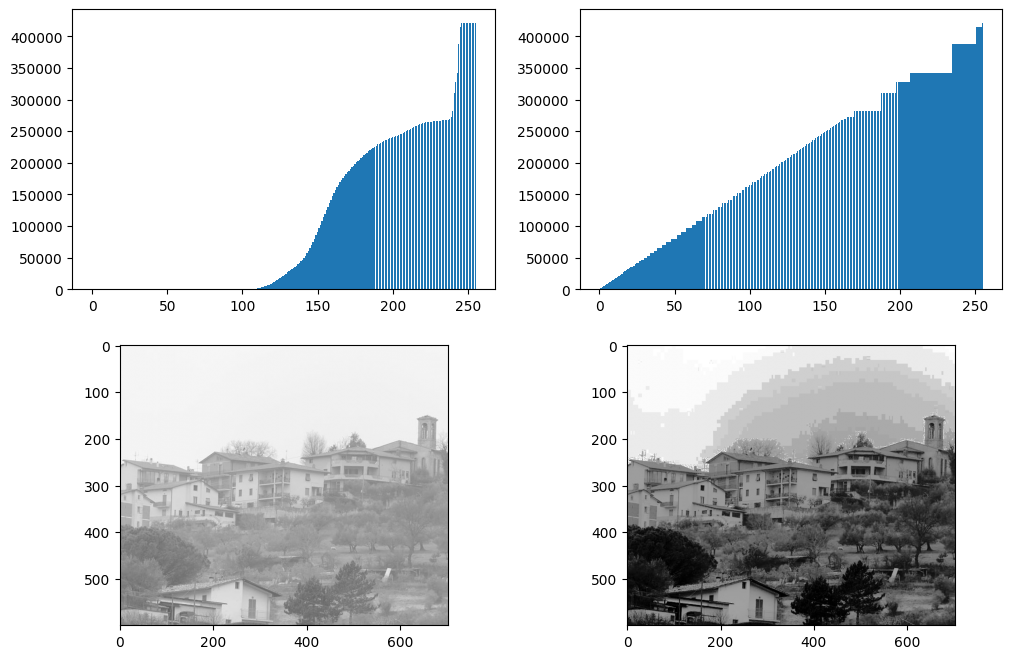

In [8]:
im = cv2.imread("/content/drive/MyDrive/res/town.jpg",cv2.IMREAD_GRAYSCALE)
hist, _ = np.histogram(im, 256, [0, 256])
cdf = hist.cumsum() # Histograma de frecuencia acumulada

im_eq = cv2.equalizeHist(im)
hist_eq, _ = np.histogram(im_eq, 256,[0,256])
cdf_eq = hist_eq.cumsum() # Histograma de frecuencia acumulada

plt.rcParams["figure.figsize"] = [12,8]
f, ax = plt.subplots(2,2)
ax[0,0].bar(range(0,256), cdf)
ax[0,1].bar(range(0,256), cdf_eq)
ax[1,0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[1,1].imshow(im_eq, cmap='gray',vmin=0, vmax=255)
plt.show()



La función anterior permite mejorar el contraste en muchas regiones de la imagen. Sin embargo, en la zona del cielo los resultados no son los esperados. Esto es debido a que en la ecualización de histograma se tiene en cuenta el contraste global de la imagen. Una forma de mejorar los resultados en ciertas zonas es utilizando una ecualización local adaptativa.

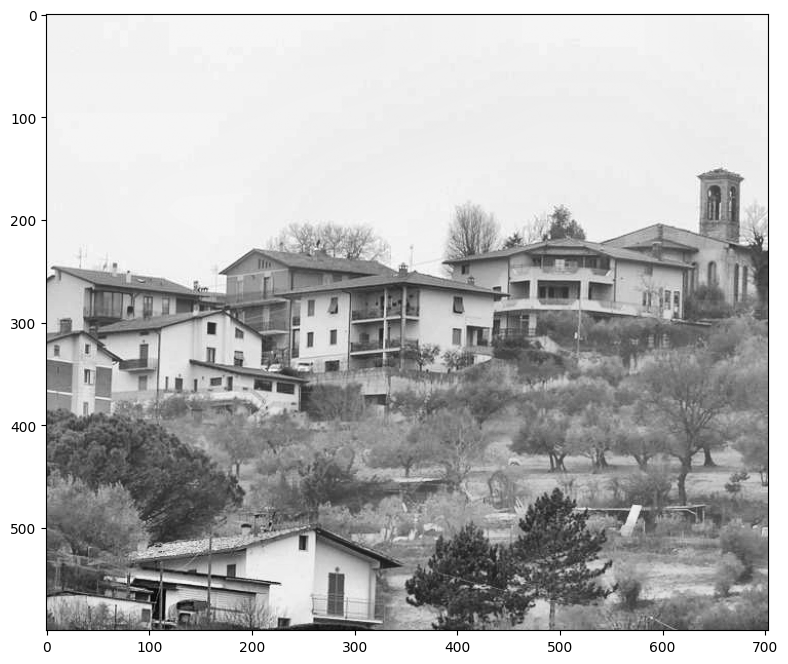

In [9]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(im)

plt.imshow(cl1,cmap='gray')
plt.show()

### Ejercicio
Aplica una expansión de histograma a la imagen `town.jpg`. Visualiza los histogramas resultantes de la ecualización global y de la expansión de histograma. Cuáles son las diferencias más significativas entre ambos?

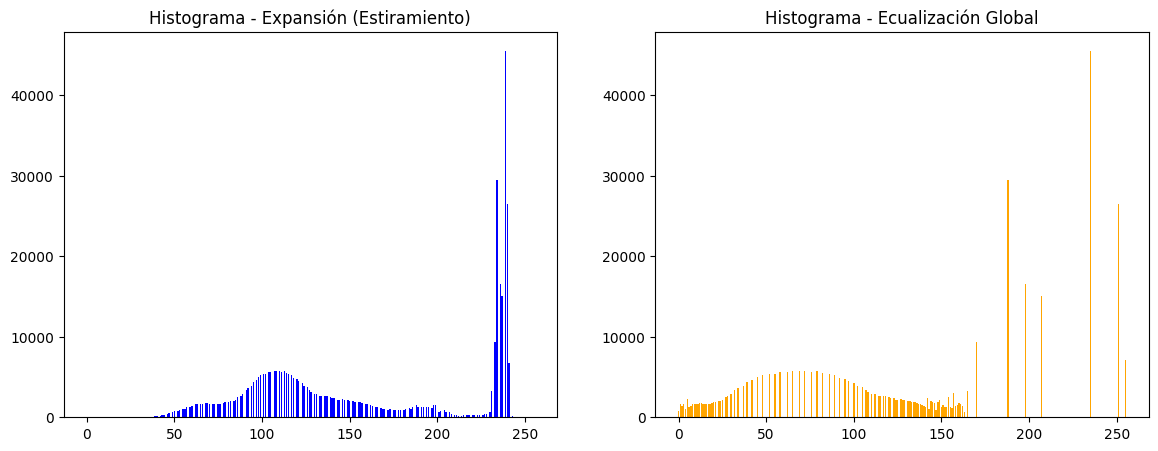

In [10]:
# Cargar imagen original
im_town = cv2.imread("/content/drive/MyDrive/res/town.jpg", cv2.IMREAD_GRAYSCALE)

# --- 1. Expansión de histograma (Estiramiento de contraste lineal) ---
im_stretched = rescale_intensity(im_town, in_range='image', out_range=(0, 255)).astype(np.uint8)
hist_stretched, _ = np.histogram(im_stretched, 256, [0, 256])

# --- 2. Ecualización global de histograma ---
im_eq = cv2.equalizeHist(im_town)
hist_eq, _ = np.histogram(im_eq, 256, [0, 256])

# Visualizar la comparación
f, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de la expansión
ax[0].bar(range(0, 256), hist_stretched, color='blue')
ax[0].set_title('Histograma - Expansión (Estiramiento)')

# Histograma de la ecualización global
ax[1].bar(range(0, 256), hist_eq, color='orange')
ax[1].set_title('Histograma - Ecualización Global')

plt.show()